In [180]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm import tqdm
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import random
import copy
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer

## Data reading & processing

In [2]:
KEYS = ['sample_id', 'sample_number', 'pocket_id']


def load_spectra(nir_path, uvvis_path, raman_path, sheet=None):
    """Load and merge three spectral datasets"""
    
    df_nir = pd.read_excel(nir_path, sheet_name=sheet) if sheet else pd.read_excel(nir_path)
    df_uvvis = pd.read_excel(uvvis_path, sheet_name=sheet) if sheet else pd.read_excel(uvvis_path)
    df_raman = pd.read_excel(raman_path, sheet_name=sheet) if sheet else pd.read_excel(raman_path)

    df_spec = (
        df_nir
        .merge(df_uvvis, on=KEYS)
        .merge(df_raman, on=KEYS)
    )

    return df_spec


def process_dataset(df_spec, df_label, seedling_col='Seedling_color'):
    """Merge label and clean dataset"""

    df = df_spec.merge(
        df_label,
        left_on=KEYS,
        right_on=['sample_id', 'Sample_Number', 'pocket_id'],
        how='inner'
    )

    # filter
    df = df[(df['Include'] == 1) & (df[seedling_col] != 0)]

    # drop unnecessary columns
    drop_cols = ['Comments', 'Include', 'Sample_Number']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # remove duplicates
    df = (
        df
        .drop_duplicates(subset=KEYS, keep='last')
        .reset_index(drop=True)
    )

    return df


# Dataset 1
df_spec_1 = load_spectra(
    'Data/2025_MS_01_NIR.xlsx',
    'Data/2025_MS_01_UVVIS.xlsx',
    'Data/2025_MS_01_Raman.xlsx'
)

df_label1 = pd.read_excel('Data/2025_MS_01_Seeds_Label.xlsx')

df_all1 = process_dataset(df_spec_1, df_label1)


# Dataset 2
df_spec_2 = load_spectra(
    'Data/MSC_2025_08_NIR.xlsx',
    'Data/MSC_2025_08_UVVIS.xlsx',
    'Data/MSC_2025_08_Raman.xlsx'
)

df_label2 = pd.read_excel('Data/MSC_2025_08_Seeds_Label.xlsx')

df_all2 = process_dataset(df_spec_2, df_label2)


# Dataset 3
df_nir3 = pd.read_excel('Data/260122_Raw_Data_Valid.xlsx', sheet_name='NIR')
df_uvvis3 = pd.read_excel('Data/260122_Raw_Data_Valid.xlsx', sheet_name='UVVIS')
df_raman3 = pd.read_excel('Data/260122_Raw_Data_Valid.xlsx', sheet_name='Raman')

df_spec_3 = df_nir3.merge(df_uvvis3, on=KEYS).merge(df_raman3, on=KEYS)

df_label3 = pd.read_excel('Data/260122_Samples_Valid.xlsx')

df_all3 = df_spec_3.merge(df_label3, on=KEYS)

df_all3 = df_all3[(df_all3['Include'] == 1) & (df_all3['Seedling coLor'] != 0)]

df_all3 = (
    df_all3
    .drop(columns=['Include_x', 'Include_y', 'Include'], errors='ignore')
    .drop_duplicates(subset=KEYS, keep='last')
    .reset_index(drop=True)
)

-> Combine NIR, UVVIS, RAMAN and the labels

-> Remove Include=0 samples

-> Remove Seedling_color=0 samples

-> Remove duplicated rows

## Modelling

In [3]:
KEYS = ["sample_id", "sample_number", "pocket_id"]

# split spectra into nir, uvvis, raman, and other info
def split_spectra(df, other_cols):

    df_id = df[KEYS]

    df_nir = pd.concat([df_id, df.iloc[:, 3:515]], axis=1)
    df_uvvis = pd.concat([df_id, df.iloc[:, 515:2583]], axis=1)
    df_raman = pd.concat([df_id, df.iloc[:, 2583:-other_cols]], axis=1)

    df_other = pd.concat([df_id, df.iloc[:, -other_cols:]], axis=1)

    return df_nir, df_uvvis, df_raman, df_other


# SNV
class SNV:
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.to_numpy()
        mu = X.mean(axis=1, keepdims=True)
        sd = X.std(axis=1, keepdims=True) + 1e-12
        return (X - mu) / sd

# SG smoothing
class SavitzkyGolay:
    def __init__(self, window_length=15, polyorder=2, deriv=0):
        self.window_length = window_length if window_length % 2 == 1 else window_length + 1
        self.polyorder = polyorder
        self.deriv = deriv

    def fit(self, X, y=None): return self

    def transform(self, X):
        out = np.empty_like(X)
        for i in range(X.shape[0]):
            out[i, :] = savgol_filter(
                X[i, :],
                window_length=self.window_length,
                polyorder=self.polyorder,
                deriv=self.deriv,
                mode="interp",
            )
        return out


# preprocess spectra
def process_spectra(df_nir, df_uvvis, df_raman):

    nir_pipeline = make_pipeline(SNV(), SavitzkyGolay(15,2,0))
    uvvis_pipeline = make_pipeline(SNV(), SavitzkyGolay(15,2,0))
    raman_pipeline = make_pipeline(SNV(), SavitzkyGolay(21,2,1))

    df_nir = df_nir.copy()
    df_uvvis = df_uvvis.copy()
    df_raman = df_raman.copy()

    nir_cols = df_nir.columns[3:]
    uvvis_cols = df_uvvis.columns[3:]
    raman_cols = df_raman.columns[3:]

    # convert spectral columns to float (safe)
    df_nir[nir_cols] = df_nir[nir_cols].astype(float)
    df_uvvis[uvvis_cols] = df_uvvis[uvvis_cols].astype(float)
    df_raman[raman_cols] = df_raman[raman_cols].astype(float)

    df_nir.loc[:, nir_cols] = nir_pipeline.fit_transform(df_nir[nir_cols])
    df_uvvis.loc[:, uvvis_cols] = uvvis_pipeline.fit_transform(df_uvvis[uvvis_cols])
    df_raman.loc[:, raman_cols] = raman_pipeline.fit_transform(df_raman[raman_cols])

    return df_nir, df_uvvis, df_raman


# merge spectra and other info
def merge_spectra(df_nir, df_uvvis, df_raman, df_other):

    return (
        df_nir
        .merge(df_uvvis, on=KEYS)
        .merge(df_raman, on=KEYS)
        .merge(df_other, on=KEYS)
    )


def clean_dataset(df, drop_cols):

    df = df.drop(columns=drop_cols, errors="ignore")

    df = df.rename(columns={
        "Seedling coLor": "Seedling_color"
    })

    return df


# process all datasets
datasets = [
    (df_all1, 4, ['Sowing ', 'Useful_plant', 'Type']),
    (df_all2, 4, ['Sowing ', 'Useful_plant']),
    (df_all3, 3, ['Useful plant: Yes (1)/No (0)'])
]

processed = []

for df, other_cols, drop_cols in datasets:

    nir, uvvis, raman, other = split_spectra(df, other_cols)
    nir, uvvis, raman = process_spectra(nir, uvvis, raman)
    df_proc = merge_spectra(nir, uvvis, raman, other)
    df_proc = clean_dataset(df_proc, drop_cols)
    processed.append(df_proc)

df_all1_proc, df_all2_proc, df_all3_proc = processed

In [4]:
# Split by Type
df_yellow = df_all3_proc[df_all3_proc['Type'] == 'StoX Yellow']
df_white = df_all3_proc[df_all3_proc['Type'] == 'StoX White']
df_silver = df_all2_proc[df_all2_proc['Type'] == 'StoX Silver']
df_ar = df_all2_proc[df_all2_proc['Type'] == 'StoX Antique Rose']
df_rp = df_all2_proc[df_all2_proc['Type'] == 'StoX Rose Pink']
df_cham = df_all2_proc[df_all2_proc['Type'] == 'StoX Champagne']
df_dr = df_all2_proc[df_all2_proc['Type'] == 'StoX Deep Rose']

In [115]:
df_image_fea

,sample_id,sample_number,seed_id,L_mean,L_std,L_q25,L_q50,L_q75,L_entropy,a_mean,...,hole_weight,n_crops_present,meanR_tip1,meanG_tip1,meanB_tip1,meanR_tip2,meanG_tip2,meanB_tip2,label,score
0,1259,MY01-01,0.0,147.581025,48.722798,102.0,153.0,184.00,3.051364,134.907895,...,0.020245,1.0,212.336842,202.200000,176.900000,161.943662,158.539906,149.962441,1,0.571551
1,1259,MY01-01,1.0,156.471483,24.088599,142.0,160.0,169.00,2.386498,147.013308,...,0.002175,1.0,205.181818,154.606061,75.318182,163.157303,109.000000,49.359551,0,0.584766
2,1259,MY01-01,2.0,112.664729,28.966065,87.0,111.0,133.00,2.580308,143.294574,...,0.000000,0.0,170.979592,130.316327,54.673469,114.092593,81.925926,55.444444,1,0.584177
3,1259,MY01-01,3.0,116.188161,18.906930,104.0,117.0,129.00,2.255136,148.122622,...,0.000000,0.0,152.610390,104.194805,57.766234,150.028986,99.304348,37.333333,0,0.530463
4,1259,MY01-01,4.0,139.647160,27.754910,116.0,139.0,164.00,2.552740,144.982788,...,0.000000,0.0,192.876289,139.618557,63.814433,136.670732,103.707317,72.768293,1,0.545357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5689,1333,MW10-26,88.0,121.625780,27.379167,102.0,117.0,135.00,2.533500,138.280665,...,0.024528,1.0,152.381579,124.157895,69.592105,146.437500,122.078125,85.515625,1,0.679520
5690,1333,MW10-26,89.0,148.626995,58.445372,99.0,140.5,201.25,3.231992,128.961436,...,0.038786,1.0,194.209402,175.760684,140.752137,174.232558,175.953488,169.809302,1,0.806028
5691,1333,MW10-26,90.0,154.779874,62.069949,101.0,151.0,213.75,3.227914,129.908805,...,0.035873,1.0,199.359833,194.246862,185.234310,196.254167,197.429167,192.108333,1,0.761779
5692,1333,MW10-26,91.0,178.757485,51.817868,132.0,180.0,227.00,3.051049,131.379042,...,0.004445,1.0,201.947368,174.954887,132.210526,213.772926,211.668122,195.611354,1,0.720978


#### Image features

In [187]:
df_image_fea = pd.read_csv('image_features.csv')
df_image_fea = df_image_fea[['sample_id', 'sample_number', 'seed_id'] + 
        [col for col in df_image_fea.columns if col not in ['sample_id', 'sample_number', 'seed_id']]]
df_image_fea = df_image_fea.iloc[:5694,:]
df_image_fea = df_image_fea.dropna(axis=1)
df_image_fea['label'] = df_image_fea['label'].map({
    'non_embryo': 0,
    'embryo': 1
})

In [188]:
# only image features
df_image_yellow = df_image_fea.merge(df_yellow[['sample_id', 'sample_number', 'pocket_id', 'Seedling_color']], left_on=['sample_id', 'sample_number', 'seed_id'], right_on=['sample_id', 'sample_number', 'pocket_id'], how='inner')
df_image_yellow = df_image_yellow.drop(columns=['pocket_id'], axis=1)
df_image_white = df_image_fea.merge(df_white[['sample_id', 'sample_number', 'pocket_id', 'Seedling_color']], left_on=['sample_id', 'sample_number', 'seed_id'], right_on=['sample_id', 'sample_number', 'pocket_id'], how='inner')
df_image_white = df_image_white.drop(columns=['pocket_id'], axis=1)
df_image_yellow = df_image_yellow.rename(columns={'seed_id': 'pocket_id'})
df_image_white = df_image_white.rename(columns={'seed_id': 'pocket_id'})

In [189]:
df_spec_yellow = df_yellow.merge(df_image_fea, left_on=['sample_id', 'sample_number', 'pocket_id'], right_on=['sample_id', 'sample_number', 'seed_id'], how='inner')[df_yellow.columns]
df_spec_white = df_white.merge(df_image_fea, left_on=['sample_id', 'sample_number', 'pocket_id'], right_on=['sample_id', 'sample_number', 'seed_id'], how='inner')[df_white.columns]

LR for image features

In [192]:
def train_logistic_pipeline(
    df,
    label_col="Seedling_color",
    group_col="sample_number",
    feature_start=3,
    feature_end=-1,
    test_size=0.2,
    random_state=42
):

    print("---- prepare data ----")
    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end].copy()

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    # find the binary columns
    binary_cols = [
        col for col in X.columns
        if set(pd.Series(X[col]).dropna().unique()).issubset({0, 1})
    ]
    continuous_cols = [col for col in X.columns if col not in binary_cols]

    print("Binary columns:", len(binary_cols))
    print("Continuous columns:", len(continuous_cols))

    # group train/test split
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # standard scaler for continuous columns
    preprocessor = ColumnTransformer(
        transformers=[
            ("cont", StandardScaler(), continuous_cols),
            ("bin", "passthrough", binary_cols)
        ],
        remainder="drop"
    )

    # CV hyperparameter search
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):

        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):

            X_tr = X_train.iloc[tr_i].copy()
            X_val = X_train.iloc[val_i].copy()

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = Pipeline([
                ("preprocessor", preprocessor),
                ("model", LogisticRegression(
                    C=C,
                    penalty="l2",
                    solver="liblinear",
                    max_iter=5000
                ))
            ])

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:, 1]
            y_pred = clf.predict(X_val)

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, y_pred))

        results.append({
            "C": C,
            "mean_auc": np.mean(auc_scores),
            "std_auc": np.std(auc_scores),
            "mean_acc": np.mean(accuracy_scores),
            "std_acc": np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc", ascending=False)
    best_C = float(cv_results.iloc[0]["C"])

    print("---- train final model ----")
    final_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=best_C,
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    final_model.fit(X_train, y_train)

    print("---- evaluate model ----")
    y_pred_train = final_model.predict_proba(X_train)[:, 1]
    y_pred_test = final_model.predict_proba(X_test)[:, 1]
    y_pred_test_class = final_model.predict(X_test)

    test_auc = roc_auc_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test_class)

    print("Best C:", best_C)
    print("Test ROC-AUC:", test_auc)
    print("Test Accuracy:", test_acc)

    print("---- precision-loss curve ----")
    y_all = np.concatenate([y_train, y_test])
    y_pred_all = np.concatenate([y_pred_train, y_pred_test])

    thresholds = np.unique(y_pred_all)

    rows = []

    for t in thresholds:
        y_pred_class = (y_pred_all >= t).astype(int)

        if y_pred_class.sum() == 0:
            continue

        p = precision_score(y_all, y_pred_class, zero_division=0)
        r = recall_score(y_all, y_pred_class, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_all, y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1 - r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "model": final_model,
        "cv_results": cv_results,
        "threshold_table": threshold_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "pred_train": y_pred_train,
        "pred_test": y_pred_test,
        "binary_cols": binary_cols,
        "continuous_cols": continuous_cols,
        "label_encoder": le
    }

In [194]:
results = train_logistic_pipeline(df_image_yellow, feature_end=-1)

---- prepare data ----
Binary columns: 3
Continuous columns: 109
---- cross-validation ----


100%|██████████| 7/7 [00:02<00:00,  3.00it/s]


---- train final model ----
---- evaluate model ----
Best C: 0.01
Test ROC-AUC: 0.5506088685341002
Test Accuracy: 0.5347368421052632
---- precision-loss curve ----


LR for spectral features

In [197]:
def train_logistic_pipeline(
    df,
    label_col="Seedling_color",
    group_col="sample_number",
    feature_start=3,
    feature_end=-1,
    test_size=0.2,
    random_state=42
):

    print("---- prepare data ----")
    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end]

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    # group train/test split
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # CV hyperparameter search
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):

        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):

            X_tr = X_train.iloc[tr_i]
            X_val = X_train.iloc[val_i]

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = LogisticRegression(
                C=C,
                penalty="l2",
                solver="liblinear",
                max_iter=5000
            )

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:,1]

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, clf.predict(X_val)))

        results.append({
            "C":C,
            "mean_auc":np.mean(auc_scores),
            "std_auc":np.std(auc_scores),
            "mean_acc":np.mean(accuracy_scores),
            "std_acc":np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc",ascending=False)

    best_C = float(cv_results.iloc[0]["C"])

    print("---- train final model ----")
    # train final model
    final_model = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=5000,
        random_state=random_state
    )

    final_model.fit(X_train,y_train)

    print("---- evaluate model ----")
    # predictions
    y_pred_train = final_model.predict_proba(X_train)[:,1]
    y_pred_test = final_model.predict_proba(X_test)[:,1]
    y_pred_test_class = final_model.predict(X_test)

    test_auc = roc_auc_score(y_test,y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test_class)

    print("Best C:",best_C)
    print("Test ROC-AUC:",test_auc)
    print("Test Accuracy:", test_acc)

    print("---- precision-loss curve ----")
    # precision-loss curve
    y_all = np.concatenate([y_train,y_test])
    y_pred_all = np.concatenate([y_pred_train,y_pred_test])

    #thresholds = np.linspace(0,1,500)
    thresholds = np.unique(y_pred_all)

    rows=[]

    for t in thresholds:

        y_pred_class = (y_pred_all>=t).astype(int)

        if y_pred_class.sum()==0:
            continue

        p = precision_score(y_all,y_pred_class,zero_division=0)
        r = recall_score(y_all,y_pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y_all,y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1-r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "model":final_model,
        "cv_results":cv_results,
        "threshold_table":threshold_df,
        "X_train":X_train,
        "X_test":X_test,
        "y_train":y_train,
        "y_test":y_test,
        "pred_train":y_pred_train,
        "pred_test":y_pred_test
    }

In [199]:
results = train_logistic_pipeline(df_spec_yellow, feature_end=-2)

---- prepare data ----
---- cross-validation ----


100%|██████████| 7/7 [04:17<00:00, 36.82s/it]


---- train final model ----
---- evaluate model ----
Best C: 1.0
Test ROC-AUC: 0.6598501792878191
Test Accuracy: 0.6273684210526316
---- precision-loss curve ----


In [163]:
df_image_white.head()

,sample_id,sample_number,pocket_id,L_mean,L_std,L_q25,L_q50,L_q75,L_entropy,a_mean,...,n_crops_present,meanR_tip1,meanG_tip1,meanB_tip1,meanR_tip2,meanG_tip2,meanB_tip2,label,score,Seedling_color
0,1296,MW06-01,2.0,133.847490,28.182354,110.0,126.0,156.0,2.434496,140.455598,...,1.0,155.333333,126.972222,93.625000,191.080000,152.933333,100.520000,0,0.591339,2
1,1296,MW06-01,3.0,104.041311,35.120992,79.0,90.0,124.0,2.597320,137.819088,...,0.0,104.523810,94.777778,87.031746,136.122137,109.167939,79.526718,0,0.515750,1
2,1296,MW06-01,4.0,140.765351,25.646120,121.0,135.0,157.0,2.497264,142.320175,...,0.0,183.913580,145.629630,87.913580,186.892308,161.769231,128.553846,0,0.647602,2
3,1296,MW06-01,5.0,113.951872,22.235400,98.0,110.0,129.0,2.379818,144.110517,...,0.0,142.409091,100.488636,50.318182,151.070423,115.070423,69.112676,0,0.723458,1
4,1296,MW06-01,6.0,157.103297,20.149777,146.0,157.0,169.5,2.326768,142.461538,...,0.0,198.236364,156.854545,81.945455,162.695122,115.829268,58.402439,0,0.669511,2


PLSDA for spectral features

In [200]:
y = df_spec_yellow["Seedling_color"]
groups = df_spec_yellow["sample_number"]
X = df_spec_yellow.iloc[:, 3:-2]

# train/test split by group
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# fix mixed-type column names
X_train.columns = X_train.columns.astype(str)
X_test.columns  = X_test.columns.astype(str)

# encode y -> 0/1
le = LabelEncoder()
y_train_binary = le.fit_transform(y_train)
y_test_binary  = le.transform(y_test)

groups_train = groups.iloc[train_idx]

# CV
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# search space
n_list = list(range(5, 41, 5))

results = []

for n in tqdm(n_list):
    fold_aucs = []
    fold_accs = []

    for tr_i, val_i in sgkf.split(X_train, y_train_binary, groups=groups_train):
        X_tr = X_train.iloc[tr_i]
        X_val = X_train.iloc[val_i]

        y_tr = y_train_binary[tr_i]
        y_val = y_train_binary[val_i]

        pls = PLSRegression(n_components=n)
        pls.fit(X_tr, y_tr)

        # continuous score for AUC
        y_val_score = pls.predict(X_val).ravel()

        # fixed threshold = 0.5 for accuracy
        y_val_pred = (y_val_score >= 0.5).astype(int)

        fold_aucs.append(roc_auc_score(y_val, y_val_score))
        fold_accs.append(accuracy_score(y_val, y_val_pred))

    results.append({
        "n_components": n,
        "mean_auc": float(np.mean(fold_aucs)),
        "std_auc": float(np.std(fold_aucs)),
        "mean_accuracy": float(np.mean(fold_accs)),
        "std_accuracy": float(np.std(fold_accs))
    })

results_df = pd.DataFrame(results).sort_values(
    ["mean_auc", "n_components"],
    ascending=[False, True]
).reset_index(drop=True)

best_row = results_df.iloc[0]
best_n = int(best_row["n_components"])

print(results_df)
print("\nBest n_components:", best_n)
print("Best CV AUC:", best_row["mean_auc"])
print("Best CV Accuracy:", best_row["mean_accuracy"])

# refit on full training set with best n_components
best_pls = PLSRegression(n_components=best_n)
best_pls.fit(X_train, y_train_binary)

# test evaluation
y_test_score = best_pls.predict(X_test).ravel()
y_test_pred = (y_test_score >= 0.5).astype(int)

test_auc = roc_auc_score(y_test_binary, y_test_score)
test_acc = accuracy_score(y_test_binary, y_test_pred)

print("\nTest AUC:", test_auc)
print("Test Accuracy:", test_acc)

100%|██████████| 8/8 [01:35<00:00, 11.97s/it]


   n_components  mean_auc   std_auc  mean_accuracy  std_accuracy
0             5  0.630771  0.038941       0.583229      0.030510
1            15  0.618158  0.038114       0.579328      0.023735
2            20  0.610927  0.042436       0.574720      0.033704
3            25  0.603830  0.037974       0.572665      0.029636
4            30  0.598049  0.037958       0.567793      0.023364
5            10  0.597095  0.033857       0.573537      0.025008
6            35  0.582987  0.034431       0.556839      0.023188
7            40  0.582874  0.038217       0.558952      0.025236

Best n_components: 5
Best CV AUC: 0.6307714211768881
Best CV Accuracy: 0.583228615880435

Test AUC: 0.6463592146838499
Test Accuracy: 0.5831578947368421


LR for merged image and spectral features (extract features from spectra first)

In [ ]:
class PLSFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=20, scale=True):
        self.n_components = n_components
        self.scale = scale

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)

        if self.scale:
            self.scaler_ = StandardScaler()
            X_scaled = self.scaler_.fit_transform(X)
        else:
            self.scaler_ = None
            X_scaled = X

        n_comp = min(self.n_components, X_scaled.shape[1], X_scaled.shape[0] - 1)
        if n_comp < 1:
            raise ValueError("Invalid number of PLS components.")

        self.n_components_ = n_comp
        self.pls_ = PLSRegression(n_components=n_comp)
        self.pls_.fit(X_scaled, y)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        if self.scale and self.scaler_ is not None:
            X_scaled = self.scaler_.transform(X)
        else:
            X_scaled = X

        # 只返回 X scores
        return self.pls_.transform(X_scaled)

def train_logistic_pipeline_merge(
    df_img,
    df_spec,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="flower_type",
    n_pls_components=15,
    test_size=0.2,
    random_state=42
):
    print("---- merge data ----")

    merge_keys = list(merge_keys)

    # 1) extract image and spectral features from original tables
    img_feature_cols_raw = df_img.columns[img_feature_start:img_feature_end].tolist()
    spec_feature_cols_raw = df_spec.columns[spec_feature_start:spec_feature_end].tolist()

    print("raw image feature cols:", len(img_feature_cols_raw))
    print("raw spectral feature cols:", len(spec_feature_cols_raw))

    # 2) avoid mixing keys / labels / group / flower into features
    exclude_img = set(merge_keys + [label_col, group_col, flower_col])
    exclude_spec = set(merge_keys + [label_col, group_col, flower_col])

    img_feature_cols_raw = [c for c in img_feature_cols_raw if c not in exclude_img]
    spec_feature_cols_raw = [c for c in spec_feature_cols_raw if c not in exclude_spec]

    print("filtered image feature cols:", len(img_feature_cols_raw))
    print("filtered spectral feature cols:", len(spec_feature_cols_raw))

    # 3) subset tables
    img_keep_cols = list(dict.fromkeys(merge_keys + img_feature_cols_raw + [label_col]))
    spec_keep_cols = list(dict.fromkeys(merge_keys + spec_feature_cols_raw + [flower_col, label_col]))

    df_img_sub = df_img[img_keep_cols].copy()
    df_spec_sub = df_spec[spec_keep_cols].copy()

    # 4) rename features to avoid collision after merge
    img_rename = {c: f"img_{c}" for c in img_feature_cols_raw}
    spec_rename = {c: f"spec_{c}" for c in spec_feature_cols_raw}

    df_img_sub = df_img_sub.rename(columns=img_rename)
    df_spec_sub = df_spec_sub.rename(columns=spec_rename)

    # merged names
    img_feature_cols = [f"img_{c}" for c in img_feature_cols_raw]
    spec_feature_cols = [f"spec_{c}" for c in spec_feature_cols_raw]
    flower_col_merged = flower_col
    label_col_merged = label_col
    group_col_merged = group_col

    # 5) merge
    df_merged = df_img_sub.merge(
        df_spec_sub,
        on=merge_keys + [label_col],
        how="inner"
    )
    df_merged.columns = df_merged.columns.map(str)

    print("Merged shape:", df_merged.shape)

    # 6) remove duplicated columns if any
    if df_merged.columns.duplicated().any():
        dup_cols = df_merged.columns[df_merged.columns.duplicated()].tolist()
        print("Found duplicated columns:", dup_cols[:20])
        df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()].copy()

    print("---- prepare data ----")

    required_cols = [label_col_merged, group_col_merged, flower_col_merged]
    missing_required = [c for c in required_cols if c not in df_merged.columns]
    if missing_required:
        raise ValueError(f"Missing required columns after merge: {missing_required}")

    # ensure selected columns exist
    img_feature_cols = [c for c in img_feature_cols if c in df_merged.columns]
    spec_feature_cols = [c for c in spec_feature_cols if c in df_merged.columns]

    print("Image feature columns:", len(img_feature_cols))
    print("Spectral feature columns:", len(spec_feature_cols))
    print("Flower column:", flower_col_merged)

    y = df_merged[label_col_merged].copy()
    groups = df_merged[group_col_merged].copy()

    # encode flower type if needed
    if df_merged[flower_col_merged].dtype == "object":
        flower_le = LabelEncoder()
        df_merged[flower_col_merged] = flower_le.fit_transform(
            df_merged[flower_col_merged].astype(str)
        )
    else:
        flower_le = None

    # final X
    X = df_merged[img_feature_cols + spec_feature_cols + [flower_col_merged]].copy()
    X.columns = X.columns.astype(str)

    if X.columns.duplicated().any():
        dup_cols = X.columns[X.columns.duplicated()].tolist()
        raise ValueError(f"Duplicated columns in X: {dup_cols[:20]}")

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    # PLS component number safety check
    max_pls = min(n_pls_components, len(spec_feature_cols), X.shape[0] - 1)
    if max_pls < 1:
        raise ValueError("n_pls_components is invalid. Spectral features may be empty.")
    if max_pls != n_pls_components:
        print(f"Adjusted n_pls_components from {n_pls_components} to {max_pls}")
    n_pls_components = max_pls

    # preprocess:
    # image -> scale
    # spectral -> scale + PLS(20)
    # flower -> passthrough
    preprocessor = ColumnTransformer(
    transformers=[
        ("img_scaled", StandardScaler(), img_feature_cols),
        ("spec_pls", PLSFeatureExtractor(n_components=n_pls_components, scale=False), spec_feature_cols),
        ("flower_pass", "passthrough", [flower_col_merged])
    ],
    remainder="drop"
)

    # train/test split by group
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # CV hyperparameter search
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):
        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):
            X_tr = X_train.iloc[tr_i].copy()
            X_val = X_train.iloc[val_i].copy()

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = Pipeline([
                ("preprocessor", preprocessor),
                ("model", LogisticRegression(
                    C=C,
                    penalty="l2",
                    solver="liblinear",
                    max_iter=5000
                ))
            ])

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:, 1]
            y_pred = clf.predict(X_val)

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, y_pred))

        results.append({
            "C": C,
            "mean_auc": np.mean(auc_scores),
            "std_auc": np.std(auc_scores),
            "mean_acc": np.mean(accuracy_scores),
            "std_acc": np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc", ascending=False)
    best_C = float(cv_results.iloc[0]["C"])

    print("---- train final model ----")
    final_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=best_C,
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    final_model.fit(X_train, y_train)

    print("---- evaluate model ----")
    y_pred_train = final_model.predict_proba(X_train)[:, 1]
    y_pred_test = final_model.predict_proba(X_test)[:, 1]
    y_pred_test_class = final_model.predict(X_test)

    test_auc = roc_auc_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test_class)

    print("Best C:", best_C)
    print("Test ROC-AUC:", test_auc)
    print("Test Accuracy:", test_acc)

    print("---- precision-loss curve ----")
    y_all = np.concatenate([y_train, y_test])
    y_pred_all = np.concatenate([y_pred_train, y_pred_test])

    thresholds = np.unique(y_pred_all)

    rows = []
    for t in thresholds:
        y_pred_class = (y_pred_all >= t).astype(int)

        if y_pred_class.sum() == 0:
            continue

        p = precision_score(y_all, y_pred_class, zero_division=0)
        r = recall_score(y_all, y_pred_class, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_all, y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1 - r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "merged_df": df_merged,
        "model": final_model,
        "cv_results": cv_results,
        "threshold_table": threshold_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "pred_train": y_pred_train,
        "pred_test": y_pred_test,
        "img_feature_cols": img_feature_cols,
        "spec_feature_cols": spec_feature_cols,
        "flower_col": flower_col_merged,
        "label_encoder": le,
        "flower_encoder": flower_le,
        "n_pls_components": n_pls_components
    }

In [204]:
results = train_logistic_pipeline_merge(
    df_image_yellow,
    df_spec_yellow,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="Type",
    n_pls_components=15,
    test_size=0.2,
    random_state=42
)

---- merge data ----
raw image feature cols: 112
raw spectral feature cols: 3624
filtered image feature cols: 112
filtered spectral feature cols: 3624
Merged shape: (2387, 3741)
---- prepare data ----
Image feature columns: 112
Spectral feature columns: 3624
Flower column: Type
---- cross-validation ----


100%|██████████| 7/7 [01:05<00:00,  9.40s/it]


---- train final model ----
---- evaluate model ----
Best C: 0.001
Test ROC-AUC: 0.6336493059253736
Test Accuracy: 0.5831578947368421
---- precision-loss curve ----


residual model

In [181]:
def train_two_stage_residual_model(
    df_img,
    df_spec,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="flower_type",
    test_size=0.2,
    random_state=42
):
    print("---- merge data ----")

    merge_keys = list(merge_keys)

    # 1) feature extraction from original tables
    img_feature_cols_raw = df_img.columns[img_feature_start:img_feature_end].tolist()
    spec_feature_cols_raw = df_spec.columns[spec_feature_start:spec_feature_end].tolist()

    exclude_img = set(merge_keys + [label_col, group_col, flower_col])
    exclude_spec = set(merge_keys + [label_col, group_col, flower_col])

    img_feature_cols_raw = [c for c in img_feature_cols_raw if c not in exclude_img]
    spec_feature_cols_raw = [c for c in spec_feature_cols_raw if c not in exclude_spec]

    print("raw image feature cols:", len(img_feature_cols_raw))
    print("raw spectral feature cols:", len(spec_feature_cols_raw))

    # 2) subset tables
    img_keep_cols = list(dict.fromkeys(merge_keys + img_feature_cols_raw + [label_col]))
    spec_keep_cols = list(dict.fromkeys(merge_keys + spec_feature_cols_raw + [flower_col, label_col]))

    df_img_sub = df_img[img_keep_cols].copy()
    df_spec_sub = df_spec[spec_keep_cols].copy()

    # 3) rename to avoid collision
    img_rename = {c: f"img_{c}" for c in img_feature_cols_raw}
    spec_rename = {c: f"spec_{c}" for c in spec_feature_cols_raw}

    df_img_sub = df_img_sub.rename(columns=img_rename)
    df_spec_sub = df_spec_sub.rename(columns=spec_rename)

    img_feature_cols = [f"img_{c}" for c in img_feature_cols_raw]
    spec_feature_cols = [f"spec_{c}" for c in spec_feature_cols_raw]

    # 4) merge
    df_merged = df_img_sub.merge(
        df_spec_sub,
        on=merge_keys + [label_col],
        how="inner"
    )
    df_merged.columns = df_merged.columns.map(str)

    if df_merged.columns.duplicated().any():
        df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()].copy()

    print("Merged shape:", df_merged.shape)

    # check required columns
    required_cols = [label_col, group_col, flower_col]
    missing_required = [c for c in required_cols if c not in df_merged.columns]
    if missing_required:
        raise ValueError(f"Missing required columns after merge: {missing_required}")

    # keep existing feature columns only
    img_feature_cols = [c for c in img_feature_cols if c in df_merged.columns]
    spec_feature_cols = [c for c in spec_feature_cols if c in df_merged.columns]

    print("Image feature columns:", len(img_feature_cols))
    print("Spectral feature columns:", len(spec_feature_cols))

    # encode flower if needed, but not used in residual branch for now
    if df_merged[flower_col].dtype == "object":
        flower_le = LabelEncoder()
        df_merged[flower_col] = flower_le.fit_transform(df_merged[flower_col].astype(str))
    else:
        flower_le = None

    y = df_merged[label_col].copy()
    groups = df_merged[group_col].copy()

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    X_spec = df_merged[spec_feature_cols].copy()
    X_img = df_merged[img_feature_cols].copy()

    # train/test split by group
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X_spec, y_binary, groups=groups))

    X_spec_train = X_spec.iloc[train_idx].copy()
    X_spec_test = X_spec.iloc[test_idx].copy()

    X_img_train = X_img.iloc[train_idx].copy()
    X_img_test = X_img.iloc[test_idx].copy()

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # stage 1: spectral LR
    # stage 2: image residual regressor
    C_list = np.logspace(-3, 3, 7)
    alpha_list = np.logspace(-3, 3, 7)

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):
        for alpha in alpha_list:
            auc_scores = []
            acc_scores = []

            for tr_i, val_i in sgkf.split(X_spec_train, y_train, groups=groups_train):
                # split
                X_spec_tr = X_spec_train.iloc[tr_i].copy()
                X_spec_val = X_spec_train.iloc[val_i].copy()

                X_img_tr = X_img_train.iloc[tr_i].copy()
                X_img_val = X_img_train.iloc[val_i].copy()

                y_tr = y_train[tr_i]
                y_val = y_train[val_i]

                # ----- stage 1: spectral LR -----
                spec_model = Pipeline([
                    ("scaler", StandardScaler()),
                    ("lr", LogisticRegression(
                        C=C,
                        penalty="l2",
                        solver="liblinear",
                        max_iter=5000,
                        random_state=random_state
                    ))
                ])

                spec_model.fit(X_spec_tr, y_tr)

                p_spec_tr = spec_model.predict_proba(X_spec_tr)[:, 1]
                p_spec_val = spec_model.predict_proba(X_spec_val)[:, 1]

                # residual target
                residual_tr = y_tr - p_spec_tr

                # ----- stage 2: image residual model -----
                residual_model = Pipeline([
                    ("scaler", StandardScaler()),
                    ("ridge", Ridge(alpha=alpha))
                ])

                residual_model.fit(X_img_tr, residual_tr)

                residual_pred_val = residual_model.predict(X_img_val)

                # final corrected probability
                p_final_val = np.clip(p_spec_val + residual_pred_val, 0, 1)
                y_pred_val = (p_final_val >= 0.5).astype(int)

                auc_scores.append(roc_auc_score(y_val, p_final_val))
                acc_scores.append(accuracy_score(y_val, y_pred_val))

            results.append({
                "C": C,
                "alpha": alpha,
                "mean_auc": np.mean(auc_scores),
                "std_auc": np.std(auc_scores),
                "mean_acc": np.mean(acc_scores),
                "std_acc": np.std(acc_scores)
            })

    cv_results = pd.DataFrame(results).sort_values("mean_auc", ascending=False)
    best_C = float(cv_results.iloc[0]["C"])
    best_alpha = float(cv_results.iloc[0]["alpha"])

    print("---- train final models ----")

    # final stage 1 model
    final_spec_model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            C=best_C,
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])
    final_spec_model.fit(X_spec_train, y_train)

    p_spec_train = final_spec_model.predict_proba(X_spec_train)[:, 1]
    p_spec_test = final_spec_model.predict_proba(X_spec_test)[:, 1]

    # final residual model
    residual_train = y_train - p_spec_train

    final_residual_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha))
    ])
    final_residual_model.fit(X_img_train, residual_train)

    residual_pred_train = final_residual_model.predict(X_img_train)
    residual_pred_test = final_residual_model.predict(X_img_test)

    # final corrected probabilities
    p_final_train = np.clip(p_spec_train + residual_pred_train, 0, 1)
    p_final_test = np.clip(p_spec_test + residual_pred_test, 0, 1)

    print("---- evaluate model ----")
    test_auc = roc_auc_score(y_test, p_final_test)
    print("Best spectral LR C:", best_C)
    print("Best residual Ridge alpha:", best_alpha)
    print("Test ROC-AUC:", test_auc)
    print("Test Accuracy:", test_acc)

    print("---- precision-loss curve ----")
    y_all = np.concatenate([y_train, y_test])
    y_pred_all = np.concatenate([p_final_train, p_final_test])

    thresholds = np.unique(y_pred_all)

    rows = []
    for t in thresholds:
        y_pred_class = (y_pred_all >= t).astype(int)

        if y_pred_class.sum() == 0:
            continue

        p = precision_score(y_all, y_pred_class, zero_division=0)
        r = recall_score(y_all, y_pred_class, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_all, y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1 - r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "merged_df": df_merged,
        "spec_model": final_spec_model,
        "residual_model": final_residual_model,
        "cv_results": cv_results,
        "threshold_table": threshold_df,
        "X_spec_train": X_spec_train,
        "X_spec_test": X_spec_test,
        "X_img_train": X_img_train,
        "X_img_test": X_img_test,
        "y_train": y_train,
        "y_test": y_test,
        "p_spec_train": p_spec_train,
        "p_spec_test": p_spec_test,
        "residual_pred_train": residual_pred_train,
        "residual_pred_test": residual_pred_test,
        "pred_train": p_final_train,
        "pred_test": p_final_test,
        "img_feature_cols": img_feature_cols,
        "spec_feature_cols": spec_feature_cols,
        "flower_col": flower_col,
        "label_encoder": le,
        "flower_encoder": flower_le
    }

In [184]:
train_two_stage_residual_model(
    df_image_yellow,
    df_spec_yellow,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="Type",
    test_size=0.2,
    random_state=42
)

---- merge data ----
raw image feature cols: 112
raw spectral feature cols: 3624
Merged shape: (2387, 3741)
Image feature columns: 112
Spectral feature columns: 3624
---- cross-validation ----


100%|██████████| 7/7 [39:31<00:00, 338.83s/it]


---- train final models ----
---- evaluate model ----
Best spectral LR C: 0.01
Best residual Ridge alpha: 1000.0
Test ROC-AUC: 0.6506550218340611
Test Accuracy: 0.6194029850746269
---- precision-loss curve ----


{'merged_df':       sample_id sample_number  pocket_id  img_L_mean  img_L_std  img_L_q25  \
 0          1259       MY01-01        2.0  112.664729  28.966065      87.00   
 1          1259       MY01-01        3.0  116.188161  18.906930     104.00   
 2          1259       MY01-01        4.0  139.647160  27.754910     116.00   
 3          1259       MY01-01        6.0  160.526096  21.914973     145.00   
 4          1259       MY01-01        8.0  159.177570  36.593323     126.00   
 ...         ...           ...        ...         ...        ...        ...   
 2382       1295       MY05-26       90.0  168.934370  23.479882     149.00   
 2383       1295       MY05-26       91.0  156.290323  43.808532     115.00   
 2384       1295       MY05-26       93.0  173.506048  25.601710     157.75   
 2385       1295       MY05-26       94.0  133.655792  50.754960      92.00   
 2386       1295       MY05-26       95.0  167.548490  33.858956     143.00   
 
       img_L_q50  img_L_q75  img_L_en

LR for merged image and spectral features (directly merge)

In [ ]:
def train_logistic_pipeline_merge(
    df_img,
    df_spec,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="Type",
    test_size=0.2,
    random_state=42
):
    print("---- merge data ----")

    merge_keys = list(merge_keys)

    # extract image and spectral features
    img_feature_cols_raw = df_img.columns[img_feature_start:img_feature_end].tolist()
    spec_feature_cols_raw = df_spec.columns[spec_feature_start:spec_feature_end].tolist()

    print("raw image feature cols:", len(img_feature_cols_raw))
    print("raw spectral feature cols:", len(spec_feature_cols_raw))

    # avoid the other columns in image and spectral features
    exclude_img = set(merge_keys + [label_col, group_col, flower_col])
    exclude_spec = set(merge_keys + [label_col, group_col, flower_col])

    img_feature_cols_raw = [c for c in img_feature_cols_raw if c not in exclude_img]
    spec_feature_cols_raw = [c for c in spec_feature_cols_raw if c not in exclude_spec]

    print("filtered image feature cols:", len(img_feature_cols_raw))
    print("filtered spectral feature cols:", len(spec_feature_cols_raw))

    # 3) 子集表
    img_keep_cols = list(dict.fromkeys(merge_keys + img_feature_cols_raw + [label_col]))
    spec_keep_cols = list(dict.fromkeys(merge_keys + spec_feature_cols_raw + [flower_col, label_col]))

    df_img_sub = df_img[img_keep_cols].copy()
    df_spec_sub = df_spec[spec_keep_cols].copy()

    # add prefix to features, avoid same names
    img_rename = {c: f"img_{c}" for c in img_feature_cols_raw}
    spec_rename = {c: f"spec_{c}" for c in spec_feature_cols_raw}

    df_img_sub = df_img_sub.rename(columns=img_rename)
    df_spec_sub = df_spec_sub.rename(columns=spec_rename)

    # merge 后真正使用的列名 
    img_feature_cols = [f"img_{c}" for c in img_feature_cols_raw]
    spec_feature_cols = [f"spec_{c}" for c in spec_feature_cols_raw]
    flower_col_merged = flower_col
    label_col_merged = label_col
    group_col_merged = group_col

    # 5) merge (?add label as the merged columns)
    df_merged = df_img_sub.merge(
        df_spec_sub,
        on=merge_keys + [label_col],
        how="inner"
    )
    df_merged.columns = df_merged.columns.map(str)

    print("Merged shape:", df_merged.shape)

    # 6) 去掉重复列，防御性处理
    if df_merged.columns.duplicated().any():
        dup_cols = df_merged.columns[df_merged.columns.duplicated()].tolist()
        print("Found duplicated columns:", dup_cols[:20])
        df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()].copy()

    print("---- prepare data ----")

    # 检查必要列
    required_cols = [label_col_merged, group_col_merged, flower_col_merged]
    missing_required = [c for c in required_cols if c not in df_merged.columns]
    if missing_required:
        raise ValueError(f"Missing required columns after merge: {missing_required}")

    # 再过滤一次，确保列存在
    img_feature_cols = [c for c in img_feature_cols if c in df_merged.columns]
    spec_feature_cols = [c for c in spec_feature_cols if c in df_merged.columns]

    print("Image feature columns:", len(img_feature_cols))
    print("Spectral feature columns:", len(spec_feature_cols))
    print("Flower column:", flower_col_merged)

    y = df_merged[label_col_merged].copy()
    groups = df_merged[group_col_merged].copy()

    # flower type 编码
    if df_merged[flower_col_merged].dtype == "object":
        flower_le = LabelEncoder()
        df_merged[flower_col_merged] = flower_le.fit_transform(
            df_merged[flower_col_merged].astype(str)
        )
    else:
        flower_le = None

    # 最终特征
    X = df_merged[img_feature_cols + spec_feature_cols + [flower_col_merged]].copy()
    X.columns = X.columns.astype(str)

    # 再次检查 X 是否有重复列
    if X.columns.duplicated().any():
        dup_cols = X.columns[X.columns.duplicated()].tolist()
        raise ValueError(f"Duplicated columns in X: {dup_cols[:20]}")

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    preprocessor = ColumnTransformer(
        transformers=[
            ("img_scaled", StandardScaler(), img_feature_cols),
            ("spec_pass", "passthrough", spec_feature_cols),
            ("flower_pass", "passthrough", [flower_col_merged])
        ],
        remainder="drop"
    )

    # train/test split by group
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # CV hyperparameter search
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):
        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):
            X_tr = X_train.iloc[tr_i].copy()
            X_val = X_train.iloc[val_i].copy()

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = Pipeline([
                ("preprocessor", preprocessor),
                ("model", LogisticRegression(
                    C=C,
                    penalty="l2",
                    solver="liblinear",
                    max_iter=5000
                ))
            ])

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:, 1]
            y_pred = clf.predict(X_val)

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, y_pred))

        results.append({
            "C": C,
            "mean_auc": np.mean(auc_scores),
            "std_auc": np.std(auc_scores),
            "mean_acc": np.mean(accuracy_scores),
            "std_acc": np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc", ascending=False)
    best_C = float(cv_results.iloc[0]["C"])

    print("---- train final model ----")
    final_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            C=best_C,
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    final_model.fit(X_train, y_train)

    print("---- evaluate model ----")
    y_pred_train = final_model.predict_proba(X_train)[:, 1]
    y_pred_test = final_model.predict_proba(X_test)[:, 1]
    y_pred_test_class = final_model.predict(X_test)

    test_auc = roc_auc_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test_class)

    print("Best C:", best_C)
    print("Test ROC-AUC:", test_auc)
    print("Test Accuracy:", test_acc)

    print("---- precision-loss curve ----")
    y_all = np.concatenate([y_train, y_test])
    y_pred_all = np.concatenate([y_pred_train, y_pred_test])

    thresholds = np.unique(y_pred_all)

    rows = []
    for t in thresholds:
        y_pred_class = (y_pred_all >= t).astype(int)

        if y_pred_class.sum() == 0:
            continue

        p = precision_score(y_all, y_pred_class, zero_division=0)
        r = recall_score(y_all, y_pred_class, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_all, y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1 - r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "merged_df": df_merged,
        "model": final_model,
        "cv_results": cv_results,
        "threshold_table": threshold_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "pred_train": y_pred_train,
        "pred_test": y_pred_test,
        "img_feature_cols": img_feature_cols,
        "spec_feature_cols": spec_feature_cols,
        "flower_col": flower_col_merged,
        "label_encoder": le,
        "flower_encoder": flower_le
    }

In [ ]:
result = train_logistic_pipeline_merge(
    df_img=df_image_white,
    df_spec=df_spec_white,
    merge_keys=("sample_id", "sample_number", "pocket_id"),
    label_col="Seedling_color",
    group_col="sample_number",
    img_feature_start=3,
    img_feature_end=-1,
    spec_feature_start=3,
    spec_feature_end=-2,
    flower_col="Type",
    test_size=0.2,
    random_state=42
)

---- merge data ----
raw image feature cols: 112
raw spectral feature cols: 3624
filtered image feature cols: 112
filtered spectral feature cols: 3624
Merged shape: (2024, 3741)
---- prepare data ----
Image feature columns: 112
Spectral feature columns: 3624
Flower column: Type
---- cross-validation ----


100%|██████████| 7/7 [09:57<00:00, 85.29s/it] 


---- train final model ----


#### 2-steps modelling

Use 1 model: 1st step (use threshold when precision=0.8 to select) -> use same model but threshold when precision=0.65 to select again and calculate the final 

In [7]:
def train_logistic_pipeline(
    df,
    label_col="Seedling_color",
    group_col="sample_number",
    feature_start=3,
    feature_end=-1,
    test_size=0.2,
    random_state=42
):

    print("---- prepare data ----")

    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end]

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    # train/test split with group shuffle
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # cross-validation
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    # parameter grid
    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")

    for C in tqdm(C_list):

        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):

            X_tr = X_train.iloc[tr_i]
            X_val = X_train.iloc[val_i]

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = LogisticRegression(
                C=C,
                penalty="l2",
                solver="liblinear",
                max_iter=5000
            )

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:,1]

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, clf.predict(X_val)))

        results.append({
            "C":C,
            "mean_auc":np.mean(auc_scores),
            "std_auc":np.std(auc_scores),
            "mean_acc":np.mean(accuracy_scores),
            "std_acc":np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc",ascending=False)

    best_C = float(cv_results.iloc[0]["C"])

    print("Best C:",best_C)

    print("---- train final model ----")

    final_model = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=5000,
        random_state=random_state
    )

    final_model.fit(X_train,y_train)

    # evaluate model
    print("---- evaluate model ----")

    y_pred_train = final_model.predict_proba(X_train)[:,1]
    y_pred_test = final_model.predict_proba(X_test)[:,1]

    test_auc = roc_auc_score(y_test,y_pred_test)

    print("Test ROC-AUC:",test_auc)

    # threshold table
    print("---- precision-loss curve ----")

    y_all = np.concatenate([y_train,y_test])
    y_pred_all = np.concatenate([y_pred_train,y_pred_test])

    thresholds = np.unique(y_pred_all)

    rows=[]

    for t in thresholds:

        y_pred_class = (y_pred_all>=t).astype(int)

        if y_pred_class.sum()==0:
            continue

        p = precision_score(y_all,y_pred_class,zero_division=0)
        r = recall_score(y_all,y_pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y_all,y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1-r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    # Two round selection strategy: 1st round for high precision (~0.8), 2nd round for remaining seeds with lower precision (~0.65)
    print("---- round 1 selection ----")

    # select threshold for round 1 (precision ~0.8)
    round1 = threshold_df.iloc[
        (threshold_df["precision"] - 0.8).abs().idxmin()
    ]

    t1 = round1["threshold"]

    round1_mask = y_pred_all >= t1

    tp1 = ((round1_mask) & (y_all == 1)).sum()
    fp1 = ((round1_mask) & (y_all == 0)).sum()

    print("Round1 threshold:",t1)
    print("Round1 precision:",round1["precision"])
    print("Round1 TP:",tp1)
    print("Round1 FP:",fp1)

    # select remaining seeds for round 2 (not predicted as double)
    remaining_mask = ~round1_mask

    y_remaining = y_all[remaining_mask]
    pred_remaining = y_pred_all[remaining_mask]

    # ROUND 2 threshold table
    thresholds2 = np.unique(pred_remaining)

    rows2=[]

    for t in thresholds2:

        pred_class = (pred_remaining>=t).astype(int)

        if pred_class.sum()==0:
            continue

        p = precision_score(y_remaining,pred_class,zero_division=0)
        r = recall_score(y_remaining,pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y_remaining,pred_class).ravel()

        rows2.append({
            "threshold":float(t),
            "precision":float(p),
            "recall":float(r),
            "loss":float(1-r),
            "tp":int(tp),
            "fp":int(fp)
        })

    round2_table = pd.DataFrame(rows2)


    print("---- round 2 selection ----")

    round2 = round2_table.iloc[
        (round2_table["precision"] - 0.65).abs().idxmin()
    ]

    t2 = round2["threshold"]

    tp2 = round2["tp"]
    fp2 = round2["fp"]

    print("Round2 threshold:",t2)
    print("Round2 precision:",round2["precision"])
    print("Round2 TP:",tp2)
    print("Round2 FP:",fp2)

    # Final results
    tp_total = tp1 + tp2
    fp_total = fp1 + fp2

    precision_final = tp_total/(tp_total+fp_total)

    total_double = (y_all==1).sum()
    loss_final = 1 - tp_total/total_double

    print("---- final results ----")

    print("Final TP:",tp_total)
    print("Final FP:",fp_total)
    print("Final precision:",precision_final)
    print("Final loss:",loss_final)

    return {
        "model":final_model,
        "cv_results":cv_results,
        "threshold_table":threshold_df,
        "round2_table":round2_table,
        "round1":round1,
        "round2":round2
    }

In [8]:
results = train_logistic_pipeline(df_yellow, feature_end=-2)

---- prepare data ----
---- cross-validation ----


100%|██████████| 7/7 [04:00<00:00, 34.38s/it]


Best C: 1.0
---- train final model ----
---- evaluate model ----
Test ROC-AUC: 0.6604059950673498
---- precision-loss curve ----
---- round 1 selection ----
Round1 threshold: 0.6798704999544507
Round1 precision: 0.8
Round1 TP: 304
Round1 FP: 76
---- round 2 selection ----
Round2 threshold: 0.6728613130354566
Round2 precision: 0.65
Round2 TP: 13.0
Round2 FP: 7.0
---- final results ----
Final TP: 317.0
Final FP: 83.0
Final precision: 0.7925
Final loss: 0.748012718600954


2 models

In [56]:
# precision-loss curve
def plot_precision_loss(
    threshold_df,
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    min_pred_pos=10,
    Type="Model"
):

    df_plot = threshold_df[
        (threshold_df["precision"] >= precision_min) &
        (threshold_df["precision"] <= precision_max)
    ]

    df_plot = df_plot[df_plot["pred_pos"] >= min_pred_pos]

    coef = np.polyfit(
        df_plot["precision"].values,
        df_plot["loss"].values,
        poly_degree
    )

    poly = np.poly1d(coef)

    plt.figure(figsize=(10,5))

    plt.plot(
        df_plot["precision"],
        df_plot["loss"],
        label="Loss"
    )

    x_grid = np.linspace(
        df_plot["precision"].min(),
        df_plot["precision"].max(),
        400
    )

    plt.plot(
        x_grid,
        poly(x_grid),
        label=f"Poly fit (deg={poly_degree})"
    )

    plt.xlabel("Double flower prediction precision")
    plt.ylabel("Loss rate of double flower seeds")

    plt.xlim(precision_min,1.0)
    plt.ylim(0,1)

    plt.grid(True,alpha=0.3)
    plt.title("Precision-Loss Curve for "+Type)
    plt.legend()

    plt.show()

    return poly

# evaluate precision at specific points
def evaluate_precision_points(poly, precision_points):

    print("---- Fitted loss values ----")

    for p in precision_points:

        loss = float(poly(p))

        print(f"precision={p:.2f} -> loss={loss:.4f}")

# build threshold table for given predictions and true labels
def build_threshold_table(pred, y):

    thresholds = np.unique(pred)

    rows=[]

    for t in thresholds:

        pred_class = (pred >= t).astype(int)
        pred_pos = pred_class.sum()

        if pred_class.sum()==0:
            continue

        p = precision_score(y,pred_class,zero_division=0)
        r = recall_score(y,pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y,pred_class).ravel()

        rows.append({
            "threshold":t,
            "precision":p,
            "recall":r,
            "loss":1-r,
            "tp":tp,
            "fp":fp,
            "pred_pos":pred_pos
        })

    return pd.DataFrame(rows)

# select threshold based on target precision
def select_threshold(table,target_precision):

    candidates = table[table["precision"] >= target_precision]

    best = candidates.sort_values("recall",ascending=False).iloc[0]

    return best

# two-stage pipeline: 1st stage for high precision selection, 2nd stage for remaining seeds with lower precision
def train_logistic_two_stage_pipeline(
        df,
        label_col="Seedling_color",
        group_col="sample_number",
        feature_start=3,
        feature_end=-1,
        test_size=0.2,
        random_state=42
):

    print("---- prepare data ----")

    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end]

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    gss = GroupShuffleSplit(n_splits=1,test_size=test_size,random_state=random_state)

    train_idx,test_idx = next(gss.split(X,y_binary,groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    sgkf = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=random_state)

    C_list = np.logspace(-3,3,7)

    # model1
    print("\n---- Model1 training ----")

    results=[]

    for C in tqdm(C_list):

        auc_scores=[]

        for tr_i,val_i in sgkf.split(X_train,y_train,groups_train):

            clf = LogisticRegression(C=C,solver="liblinear",max_iter=5000)

            clf.fit(X_train.iloc[tr_i],y_train[tr_i])

            pred = clf.predict_proba(X_train.iloc[val_i])[:,1]

            auc_scores.append(roc_auc_score(y_train[val_i],pred))

        results.append({"C":C,"auc":np.mean(auc_scores)})

    best_C = pd.DataFrame(results).sort_values("auc",ascending=False).iloc[0]["C"]

    model1 = LogisticRegression(C=best_C,solver="liblinear",max_iter=5000)

    model1.fit(X_train,y_train)

    pred1_train = model1.predict_proba(X_train)[:,1]
    pred1_test = model1.predict_proba(X_test)[:,1]

    pred1_all = np.concatenate([pred1_train,pred1_test])
    y_all = np.concatenate([y_train,y_test])

    print("Model1 AUC:",roc_auc_score(y_test,pred1_test))

    # precision-loss curve
    model1_table = build_threshold_table(pred1_all,y_all)

    poly1 = plot_precision_loss(model1_table,Type="Silver - Model1")
    evaluate_precision_points(
    poly1,
    [0.85,0.8,0.75,0.7,0.65,0.6]
)

    # select threshold when precision ~0.8
    round1 = select_threshold(model1_table,0.8)

    t1 = round1["threshold"]

    print("Round1 threshold:",t1)

    # remove selected seeds for round 2
    pred1_train_class = pred1_train >= t1
    pred1_test_class = pred1_test >= t1

    X_train_remain = X_train[~pred1_train_class]
    y_train_remain = y_train[~pred1_train_class]
    groups_train_remain = groups_train[~pred1_train_class]

    X_test_remain = X_test[~pred1_test_class]
    y_test_remain = y_test[~pred1_test_class]

    # model2
    print("\n---- Model2 training ----")

    model2 = LogisticRegression(C=best_C,solver="liblinear",max_iter=5000, class_weight="balanced")

    model2.fit(X_train_remain,y_train_remain)

    pred2_train = model2.predict_proba(X_train_remain)[:,1]
    pred2_test = model2.predict_proba(X_test_remain)[:,1]

    pred2_all = np.concatenate([pred2_train,pred2_test])
    y_remain_all = np.concatenate([y_train_remain,y_test_remain])

    print("Model2 AUC:",roc_auc_score(y_test_remain,pred2_test))

    model2_table = build_threshold_table(pred2_all,y_remain_all)

    poly2 = plot_precision_loss(model2_table, poly_degree=4, Type="Silver - Model2")
    evaluate_precision_points(
    poly2,
    [0.85,0.8,0.75,0.7,0.65,0.6]
)

    round2 = select_threshold(model2_table,0.65)

    t2 = round2["threshold"]

    print("Round2 threshold:",t2)

    # final results
    pred2_test_class = pred2_test >= t2

    tp1 = ((pred1_test_class)&(y_test==1)).sum()
    fp1 = ((pred1_test_class)&(y_test==0)).sum()

    tp2 = ((pred2_test_class)&(y_test_remain==1)).sum()
    fp2 = ((pred2_test_class)&(y_test_remain==0)).sum()

    tp_total = tp1 + tp2
    fp_total = fp1 + fp2

    precision_final = tp_total/(tp_total+fp_total)

    total_double = (y_test==1).sum()

    loss_final = 1 - tp_total/total_double

    print("\n---- final results ----")

    print("Final TP1:",tp1)
    print("Final FP1:",fp1)
    print("Final TP2:",tp2)
    print("Final FP2:",fp2)
    print("Final precision:",precision_final)
    print("Final loss:",loss_final)

    return

---- prepare data ----

---- Model1 training ----


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [01:14<00:00, 10.70s/it]


Model1 AUC: 0.7402081362346263


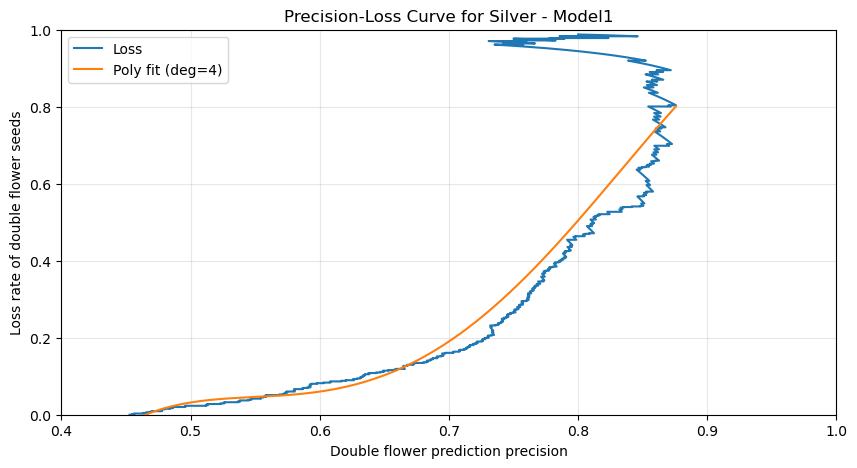

---- Fitted loss values ----
precision=0.85 -> loss=0.7019
precision=0.80 -> loss=0.5045
precision=0.75 -> loss=0.3270
precision=0.70 -> loss=0.1902
precision=0.65 -> loss=0.1026
precision=0.60 -> loss=0.0601
Round1 threshold: 0.6206160189153674

---- Model2 training ----
Model2 AUC: 0.6794761700300558


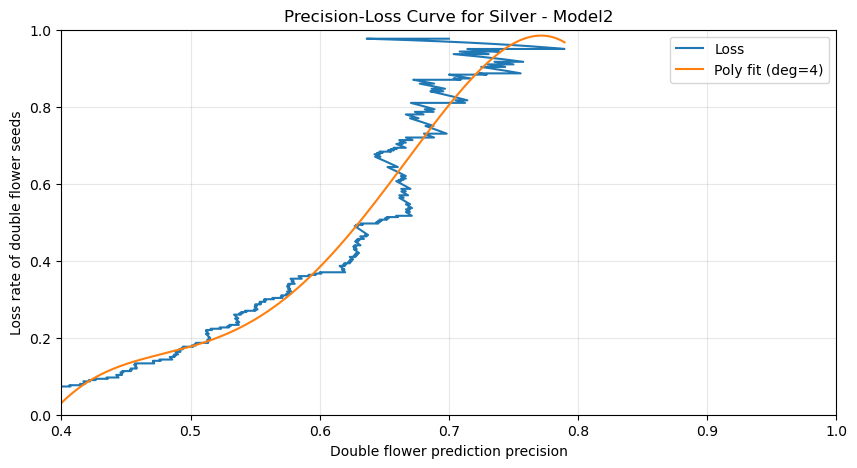

---- Fitted loss values ----
precision=0.85 -> loss=0.5641
precision=0.80 -> loss=0.9391
precision=0.75 -> loss=0.9642
precision=0.70 -> loss=0.8042
precision=0.65 -> loss=0.5830
precision=0.60 -> loss=0.3835
Round2 threshold: 0.611172354946271

---- final results ----
Final TP1: 83
Final FP1: 38
Final TP2: 29
Final FP2: 20
Final precision: 0.6588235294117647
Final loss: 0.2582781456953642


In [57]:
train_logistic_two_stage_pipeline(df_silver, feature_end=-2)

In [40]:
def plot_precision_loss(
    threshold_df,
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    min_pred_pos=50,
    Type="Model"
):

    df_plot = threshold_df[
        (threshold_df["precision"] >= precision_min) &
        (threshold_df["precision"] <= precision_max)
    ]

    df_plot = df_plot[df_plot["pred_pos"] >= min_pred_pos]

    coef = np.polyfit(
        df_plot["precision"].values,
        df_plot["loss"].values,
        poly_degree
    )

    poly = np.poly1d(coef)

    plt.figure(figsize=(10,5))

    plt.plot(
        df_plot["precision"],
        df_plot["loss"],
        label="Loss"
    )

    x_grid = np.linspace(
        df_plot["precision"].min(),
        df_plot["precision"].max(),
        400
    )

    plt.plot(
        x_grid,
        poly(x_grid),
        label=f"Poly fit (deg={poly_degree})"
    )

    plt.xlabel("Double flower prediction precision")
    plt.ylabel("Loss rate of double flower seeds")

    plt.xlim(precision_min,1.0)
    plt.ylim(0,1)

    plt.grid(True,alpha=0.3)
    plt.title("Precision-Loss Curve for "+Type)
    plt.legend()

    plt.show()

    return poly

def evaluate_precision_points(poly, precision_points):

    print("---- Fitted loss values ----")

    for p in precision_points:

        loss = float(poly(p))

        print(f"precision={p:.2f} -> loss={loss:.4f}")

def build_threshold_table(pred, y):

    thresholds = np.unique(pred)

    rows=[]

    for t in thresholds:

        pred_class = (pred >= t).astype(int)
        pred_pos = pred_class.sum()

        if pred_class.sum()==0:
            continue

        p = precision_score(y,pred_class,zero_division=0)
        r = recall_score(y,pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y,pred_class).ravel()

        rows.append({
            "threshold":t,
            "precision":p,
            "recall":r,
            "loss":1-r,
            "tp":tp,
            "fp":fp,
            "pred_pos":pred_pos
        })

    return pd.DataFrame(rows)

def select_threshold(table,target_precision):

    candidates = table[table["precision"] >= target_precision]

    best = candidates.sort_values("recall",ascending=False).iloc[0]

    return best

def train_logistic_two_stage_pipeline(
        df,
        label_col="Seedling_color",
        group_col="sample_number",
        feature_start=3,
        feature_end=-1,
        test_size=0.2,
        random_state=42
):

    print("---- prepare data ----")

    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end]

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    gss = GroupShuffleSplit(n_splits=1,test_size=test_size,random_state=random_state)

    train_idx,test_idx = next(gss.split(X,y_binary,groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    sgkf = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=random_state)

    C_list = np.logspace(-3,3,7)

    # -------------------
    # Model1
    # -------------------

    print("\n---- Model1 training ----")

    results=[]

    for C in tqdm(C_list):

        auc_scores=[]

        for tr_i,val_i in sgkf.split(X_train,y_train,groups_train):

            clf = LogisticRegression(C=C,solver="liblinear",max_iter=5000)

            clf.fit(X_train.iloc[tr_i],y_train[tr_i])

            pred = clf.predict_proba(X_train.iloc[val_i])[:,1]

            auc_scores.append(roc_auc_score(y_train[val_i],pred))

        results.append({"C":C,"auc":np.mean(auc_scores)})

    best_C = pd.DataFrame(results).sort_values("auc",ascending=False).iloc[0]["C"]

    model1 = LogisticRegression(C=best_C,solver="liblinear",max_iter=5000)

    model1.fit(X_train,y_train)

    pred1_train = model1.predict_proba(X_train)[:,1]
    pred1_test = model1.predict_proba(X_test)[:,1]

    pred1_all = np.concatenate([pred1_train,pred1_test])
    y_all = np.concatenate([y_train,y_test])

    print("Model1 AUC:",roc_auc_score(y_test,pred1_test))

    # precision-loss curve
    model1_table = build_threshold_table(pred1_all,y_all)

    poly1 = plot_precision_loss(model1_table,Type="Yellow - Model1")
    evaluate_precision_points(
    poly1,
    [0.85,0.8,0.75,0.7,0.65,0.6]
)

    # select threshold
    round1 = select_threshold(model1_table,0.8)

    t1 = round1["threshold"]

    print("Round1 threshold:",t1)

    # -------------------
    # remove selected seeds
    # -------------------

    pred1_train_class = pred1_train >= t1
    pred1_test_class = pred1_test >= t1

    X_train_remain = X_train[~pred1_train_class]
    y_train_remain = y_train[~pred1_train_class]
    groups_train_remain = groups_train[~pred1_train_class]

    X_test_remain = X_test[~pred1_test_class]
    y_test_remain = y_test[~pred1_test_class]

    # -------------------
    # Model2
    # -------------------

    print("\n---- Model2 training (PLS-DA) ----")

    components_list = list(range(5,41,5))

    results2 = []

    for n_comp in tqdm(components_list):

        auc_scores = []

        for tr_i,val_i in sgkf.split(X_train_remain,y_train_remain,groups_train_remain):

            X_tr = X_train_remain.iloc[tr_i]
            X_val = X_train_remain.iloc[val_i]

            y_tr = y_train_remain[tr_i]
            y_val = y_train_remain[val_i]

            pls = PLSRegression(n_components=n_comp)

            pls.fit(X_tr,y_tr)

            pred = pls.predict(X_val).ravel()

            auc_scores.append(roc_auc_score(y_val,pred))

        results2.append({
            "n_components":n_comp,
            "auc":np.mean(auc_scores)
        })


    cv_results2 = pd.DataFrame(results2).sort_values("auc",ascending=False)

    best_comp = int(cv_results2.iloc[0]["n_components"])

    print("Best PLS components:",best_comp)

    model2 = PLSRegression(n_components=best_comp)
    model2.fit(X_train_remain,y_train_remain)

    pred2_train = model2.predict(X_train_remain).ravel()
    pred2_test = model2.predict(X_test_remain).ravel()

    print("Model2 AUC:",roc_auc_score(y_test_remain,pred2_test))

    pred2_all = np.concatenate([pred2_train,pred2_test])
    y_remain_all = np.concatenate([y_train_remain,y_test_remain])

    model2_table = build_threshold_table(pred2_all,y_remain_all)

    poly2 = plot_precision_loss(model2_table,Type="Yellow - Model2")
    evaluate_precision_points(
    poly2,
    [0.85,0.8,0.75,0.7,0.65,0.6]
)

    round2 = select_threshold(model2_table,0.65)

    t2 = round2["threshold"]

    print("Round2 threshold:",t2)

    # -------------------
    # final results
    # -------------------

    pred2_test_class = pred2_test >= t2

    tp1 = ((pred1_test_class)&(y_test==1)).sum()
    fp1 = ((pred1_test_class)&(y_test==0)).sum()

    tp2 = ((pred2_test_class)&(y_test_remain==1)).sum()
    fp2 = ((pred2_test_class)&(y_test_remain==0)).sum()

    tp_total = tp1 + tp2
    fp_total = fp1 + fp2

    precision_final = tp_total/(tp_total+fp_total)

    total_double = (y_test==1).sum()

    loss_final = 1 - tp_total/total_double

    print("\n---- final results ----")

    print("Final precision:",precision_final)
    print("Final loss:",loss_final)

    return

---- prepare data ----

---- Model1 training ----


100%|██████████| 7/7 [04:45<00:00, 40.81s/it]


Model1 AUC: 0.6604059950673498


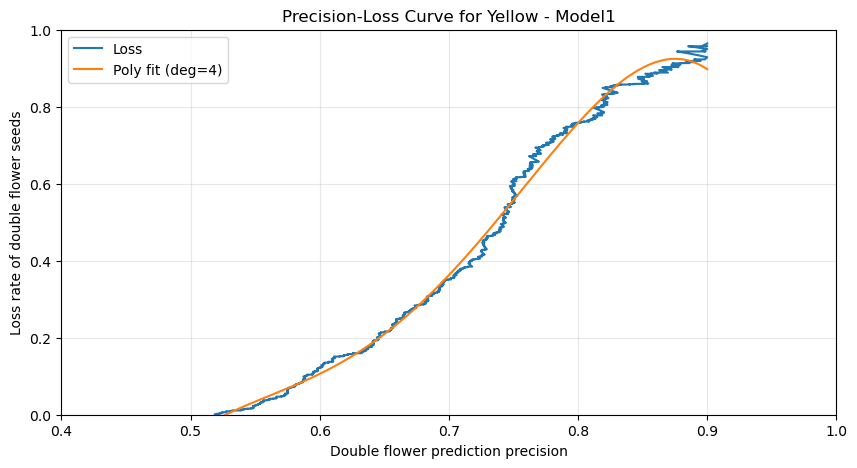

---- Fitted loss values ----
precision=0.85 -> loss=0.9012
precision=0.80 -> loss=0.7578
precision=0.75 -> loss=0.5573
precision=0.70 -> loss=0.3626
precision=0.65 -> loss=0.2094
precision=0.60 -> loss=0.1061
Round1 threshold: 0.6798704999544507

---- Model2 training (PLS-DA) ----


100%|██████████| 8/8 [01:23<00:00, 10.45s/it]


Best PLS components: 5
Model2 AUC: 0.6263488372093023


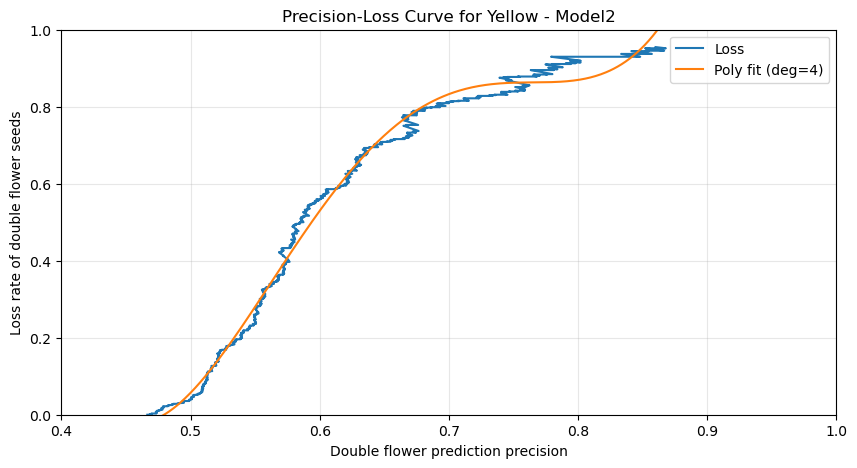

---- Fitted loss values ----
precision=0.85 -> loss=0.9547
precision=0.80 -> loss=0.8696
precision=0.75 -> loss=0.8624
precision=0.70 -> loss=0.8327
precision=0.65 -> loss=0.7253
precision=0.60 -> loss=0.5297
Round2 threshold: 0.5843674778864287

---- final results ----
Final precision: 0.7058823529411765
Final loss: 0.5219123505976095


In [41]:
train_logistic_two_stage_pipeline(df_yellow, feature_end=-2)

#### Model training + precision-loss curve

In [ ]:
def train_logistic_pipeline(
    df,
    label_col="Seedling_color",
    group_col="sample_number",
    feature_start=3,
    feature_end=-1,
    test_size=0.2,
    random_state=42
):

    print("---- prepare data ----")
    y = df[label_col]
    groups = df[group_col]
    X = df.iloc[:, feature_start:feature_end]

    X.columns = X.columns.astype(str)

    le = LabelEncoder()
    y_binary = le.fit_transform(y)

    # group train/test split
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_binary[train_idx]
    y_test = y_binary[test_idx]

    groups_train = groups.iloc[train_idx]

    # CV hyperparameter search
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    C_list = np.logspace(-3, 3, 7)

    results = []

    print("---- cross-validation ----")
    for C in tqdm(C_list):

        auc_scores = []
        accuracy_scores = []

        for tr_i, val_i in sgkf.split(X_train, y_train, groups=groups_train):

            X_tr = X_train.iloc[tr_i]
            X_val = X_train.iloc[val_i]

            y_tr = y_train[tr_i]
            y_val = y_train[val_i]

            clf = LogisticRegression(
                C=C,
                penalty="l2",
                solver="liblinear",
                max_iter=5000
            )

            clf.fit(X_tr, y_tr)

            y_proba = clf.predict_proba(X_val)[:,1]

            auc_scores.append(roc_auc_score(y_val, y_proba))
            accuracy_scores.append(accuracy_score(y_val, clf.predict(X_val)))

        results.append({
            "C":C,
            "mean_auc":np.mean(auc_scores),
            "std_auc":np.std(auc_scores),
            "mean_acc":np.mean(accuracy_scores),
            "std_acc":np.std(accuracy_scores)
        })

    cv_results = pd.DataFrame(results).sort_values("mean_auc",ascending=False)

    best_C = float(cv_results.iloc[0]["C"])

    print("---- train final model ----")
    # train final model
    final_model = LogisticRegression(
        C=best_C,
        solver="liblinear",
        max_iter=5000,
        random_state=random_state
    )

    final_model.fit(X_train,y_train)

    print("---- evaluate model ----")
    # predictions
    y_pred_train = final_model.predict_proba(X_train)[:,1]
    y_pred_test = final_model.predict_proba(X_test)[:,1]

    test_auc = roc_auc_score(y_test,y_pred_test)

    print("Best C:",best_C)
    print("Test ROC-AUC:",test_auc)

    print("---- precision-loss curve ----")
    # precision-loss curve
    y_all = np.concatenate([y_train,y_test])
    y_pred_all = np.concatenate([y_pred_train,y_pred_test])

    #thresholds = np.linspace(0,1,500)
    thresholds = np.unique(y_pred_all)

    rows=[]

    for t in thresholds:

        y_pred_class = (y_pred_all>=t).astype(int)

        if y_pred_class.sum()==0:
            continue

        p = precision_score(y_all,y_pred_class,zero_division=0)
        r = recall_score(y_all,y_pred_class,zero_division=0)

        tn,fp,fn,tp = confusion_matrix(y_all,y_pred_class).ravel()

        rows.append({
            "threshold": float(t),
            "precision": float(p),
            "recall": float(r),
            "loss": float(1-r),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "pred_pos": int(tp + fp)
        })

    threshold_df = pd.DataFrame(rows)

    return {
        "model":final_model,
        "cv_results":cv_results,
        "threshold_table":threshold_df,
        "X_train":X_train,
        "X_test":X_test,
        "y_train":y_train,
        "y_test":y_test,
        "pred_train":y_pred_train,
        "pred_test":y_pred_test
    }

In [28]:
def plot_precision_loss(
    threshold_df,
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    filter = False,
    Type="Yellow"
):

    df_plot = threshold_df[
        (threshold_df["precision"] >= precision_min) &
        (threshold_df["precision"] <= precision_max)
    ]

    if filter is not False:
        df_plot = df_plot[df_plot["pred_pos"] >= 40].reset_index(drop=True)
        
    # polynomial fit
    coef = np.polyfit(
        df_plot["precision"].values,
        df_plot["loss"].values,
        poly_degree
    )

    poly = np.poly1d(coef)

    plt.figure(figsize=(10,5))

    plt.plot(
        df_plot["precision"],
        df_plot["loss"],
        label="Loss (Train + Test)"
    )

    x_grid = np.linspace(
        df_plot["precision"].min(),
        df_plot["precision"].max(),
        400
    )

    y_grid = poly(x_grid)

    plt.plot(
        x_grid,
        y_grid,
        label=f"Poly fit (deg={poly_degree})"
    )

    plt.xlabel("Double flower prediction precision")
    plt.ylabel("Loss rate of double flower seeds")

    plt.xlim(precision_min,1.0)
    plt.ylim(0.0,1.0)

    plt.grid(True,alpha=0.3)

    plt.title("Precision-Loss Curve for "+Type+" Type")

    plt.legend()

    plt.show()

    return poly


def evaluate_precision_points(poly, precision_points):

    print("---- Fitted loss values ----:")

    for p in precision_points:

        loss = float(poly(p))

        print(f"precision={p:.2f} -> fitted loss={loss:.4f}")

In [37]:
results = train_logistic_pipeline(df_yellow, feature_end=-2)

---- prepare data ----
---- cross-validation ----


 29%|██▊       | 2/7 [00:07<00:19,  3.99s/it]


KeyboardInterrupt: 

In [22]:
results["cv_results"]

,C,mean_auc,std_auc
3,1.000,0.605537,0.031506
4,10.000,0.592513,0.029975
2,0.100,0.583918,0.053566
5,100.000,0.569084,0.022829
1,0.010,0.560180,0.050036
6,1000.000,0.546337,0.026822
0,0.001,0.528206,0.037523


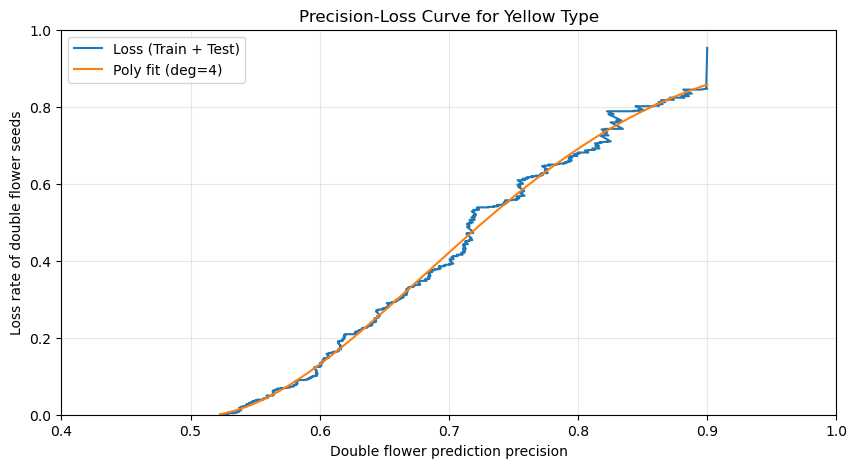

---- Fitted loss values ----:
precision=0.60 -> fitted loss=0.1310
precision=0.65 -> fitted loss=0.2698
precision=0.70 -> fitted loss=0.4212
precision=0.75 -> fitted loss=0.5659
precision=0.80 -> fitted loss=0.6908
precision=0.85 -> fitted loss=0.7885


In [30]:
poly = plot_precision_loss(
    results["threshold_table"],
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    Type="Yellow"
)

precision_points = [0.60,0.65,0.70,0.75,0.80,0.85]

evaluate_precision_points(poly, precision_points)

---- prepare data ----
---- cross-validation ----


100%|██████████| 7/7 [03:45<00:00, 32.19s/it]


---- train final model ----
---- evaluate model ----
Best C: 1.0
Test ROC-AUC: 0.7322542810227539
---- precision-loss curve ----


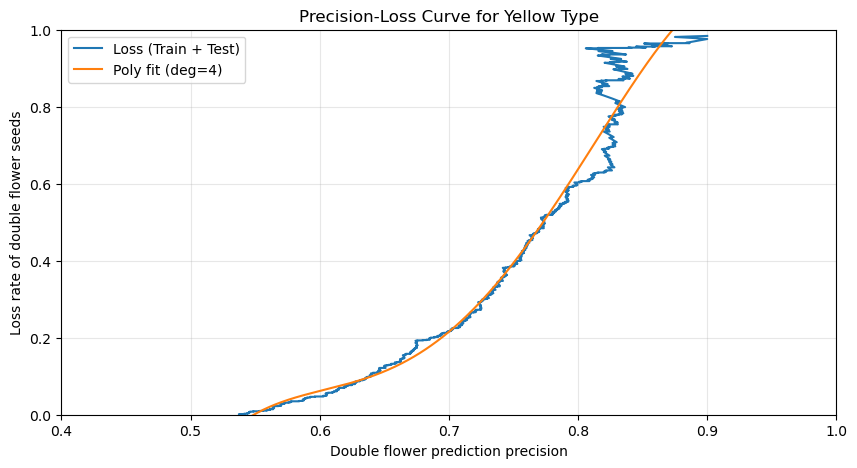

---- Fitted loss values ----:
precision=0.60 -> fitted loss=0.0616
precision=0.65 -> fitted loss=0.1125
precision=0.70 -> fitted loss=0.2153
precision=0.75 -> fitted loss=0.3944
precision=0.80 -> fitted loss=0.6376
precision=0.85 -> fitted loss=0.8966


In [32]:
results = train_logistic_pipeline(df_white, feature_end=-2)

poly = plot_precision_loss(
    results["threshold_table"],
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    Type="Yellow"
)

precision_points = [0.60,0.65,0.70,0.75,0.80,0.85]

evaluate_precision_points(poly, precision_points)

---- prepare data ----
---- cross-validation ----


100%|██████████| 7/7 [01:56<00:00, 16.59s/it]


---- train final model ----
---- evaluate model ----
Best C: 10.0
Test ROC-AUC: 0.7402081362346263
---- precision-loss curve ----


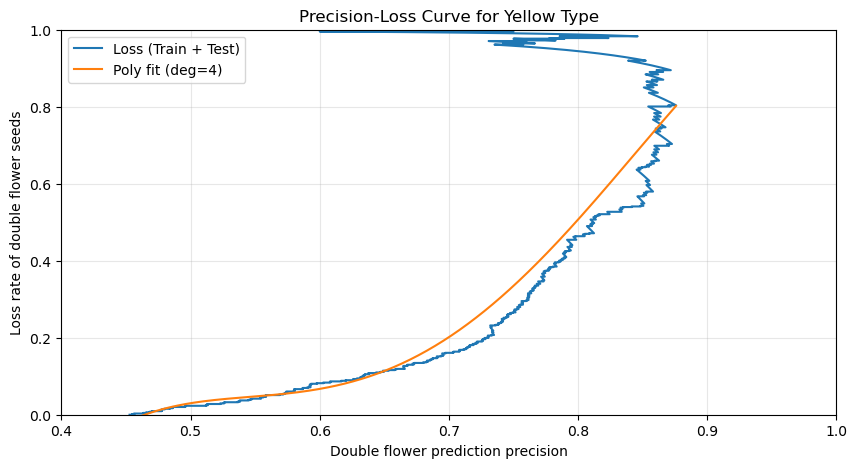

---- Fitted loss values ----:
precision=0.60 -> fitted loss=0.0671
precision=0.65 -> fitted loss=0.1136
precision=0.70 -> fitted loss=0.2015
precision=0.75 -> fitted loss=0.3347
precision=0.80 -> fitted loss=0.5069
precision=0.85 -> fitted loss=0.7014


In [33]:
results = train_logistic_pipeline(df_silver, feature_end=-2)

poly = plot_precision_loss(
    results["threshold_table"],
    precision_min=0.4,
    precision_max=0.9,
    poly_degree=4,
    Type="Yellow"
)

precision_points = [0.60,0.65,0.70,0.75,0.80,0.85]

evaluate_precision_points(poly, precision_points)